# Jupyter Notebook for "Two-Colour Phase Control of High-Harmonic Generation from Relativistic Plasma Mirrors" Report

In [ ]:
# Imports
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from sdf_xarray import SDFPreprocess
import scipy as sp
from ipywidgets import interact
from scipy.signal import hilbert
from scipy import stats
import os
import re
import glob

In [6]:
# Constants
c = 299792458
eps_0 = 8.854e-12
mu_0 = 4e-7 * np.pi
lambda_0 = 1.0e-6
f0 = c / lambda_0
omega0 = 2 * np.pi * f0

In [ ]:
def run_FFT(data_file):

    # Selects nearest gridpoint to some x position and extracts Ey and time data
    probe_x_idx = np.argmin(np.abs(data_file['X_Grid_mid'].values - 10e-6)) 
    Ey_t = data_file['Electric_Field_Ey'].isel(X_Grid_mid=probe_x_idx).values
    t = data_file['time'].values

    # Mask to select time window containing the reflected pulse
    reflected_mask = (t > 4e-13) & (t < 5.75e-13)
    Ey_reflected = Ey_t[reflected_mask]
    t_reflected = t[reflected_mask]

    # FFT
    dt = t_reflected[1] - t_reflected[0]
    Ey_FT = sp.fft.fftshift(sp.fft.fft(Ey_reflected)) * dt
    omega_vals = sp.fft.fftshift(sp.fft.fftfreq(len(t_reflected), d=dt)) * 2 * np.pi

    return Ey_FT, omega_vals, dt, t_reflected


def extract_rel_phase(directory):
    deck_path = os.path.join(directory, "input.deck")
    try:
        with open(deck_path, 'r') as file:
            content = file.read()
            match = re.search(r'rel_phase\s*=\s*([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?)', content)
            if match:
                return float(match.group(1))
            else:
                print(f"Could not find rel_phase in {deck_path}")
                return None
    except FileNotFoundError:
        print(f"Error: Could not find {deck_path}")
        return None
    

def find_harmonic_peaks(omega_vals, Ey_FT, max_harmonic=14, plot=False, odd_only=False):

    # Compute power spectrum and select positive frequencies only to avoid counting peaks twice
    power = np.abs(Ey_FT)**2
    positive_mask = omega_vals > 0
    omega_pos = omega_vals[positive_mask]
    power_pos = power[positive_mask]

    harmonic_peak_omegas = {}
    harmonic_peak_powers = {}

    # Search for fundamental peak and store omega and "power" in dictionaries with key 1
    search_mask = (omega_pos > 0.5 * omega0) & (omega_pos < 1.5 * omega0)
    idx = np.argmax(power_pos * search_mask)
    harmonic_peak_omegas[1] = omega_pos[idx]
    harmonic_peak_powers[1] = power_pos[idx]

    # Search for the other harmonics
    for n in range(2, max_harmonic + 1):

        # Skip even harmonics in the case of single-colour drive
        if odd_only and n % 2 == 0:
            continue

        found_ns = np.array(list(harmonic_peak_omegas.keys()))
        found_omegas = np.array(list(harmonic_peak_omegas.values()))

        # If two or more harmonics have been detected, fit a straight line through them to make up for the Doppler shift trend
        if len(found_ns) >= 2:
            coeffs = np.polyfit(found_ns, found_omegas, 1)
            expected = np.polyval(coeffs, n)

        # If only one harmonic has been detected, just predict position to be one omega_0 to the right  
        elif len(found_ns) == 1:
            expected = harmonic_peak_omegas[1] + (n - 1) * omega0
        else:
            continue
        
        # Define a mask around the predicted position
        search_mask = (omega_pos > expected - 0.6 * omega0) & \
                      (omega_pos < expected + 0.6 * omega0)

        # Skip iteration if no frequency points are found
        if not search_mask.any():
            continue

        # Find strongest peak in the window
        local_power = power_pos * search_mask
        idx = np.argmax(local_power)

        # Determine whether an actual harmonic or just noise
        if local_power[idx] > power_pos.max() * 0.00002:
            potential_omega = omega_pos[idx]
            
            # Check for consistency with Doppler shift trend
            if len(found_ns) >= 2:
                predicted_shift = np.polyval(coeffs, n) - n * omega0
                actual_shift = potential_omega - n * omega0

                if abs(actual_shift - predicted_shift) < 0.4 * omega0:
                    harmonic_peak_omegas[n] = potential_omega
                    harmonic_peak_powers[n] = power_pos[idx]
            else:
                harmonic_peak_omegas[n] = potential_omega
                harmonic_peak_powers[n] = power_pos[idx]

    # Print detected harmonics
    print("Detected harmonics:")
    for n, peak_omega in harmonic_peak_omegas.items():
        print(f"  H{n}: omega = {peak_omega/omega0:.3f} omega0 | "
              f"theoretical = {n:.1f} omega0 | "
              f"power = {harmonic_peak_powers[n]:.3e}")

    # Plot
    if plot:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.semilogy(omega_vals / omega0, np.abs(Ey_FT)**2)
        ax.set_xlim(0, max_harmonic + 1)
        ax.set_xlabel(r'$\omega / \omega_0$')
        ax.set_ylabel(r'|E$_y$($\omega$)|$^2$')
        ax.grid(True)

        for n, peak_omega in harmonic_peak_omegas.items():
            ax.axvline(peak_omega / omega0, color='red', linewidth=0.8, linestyle='--', alpha=0.7)
            ax.text(peak_omega / omega0, ax.get_ylim()[1], f'H{n}',
                    color='red', fontsize=7, ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

    return harmonic_peak_omegas, harmonic_peak_powers


def plot_spectral_map(folder, max_harmonic=12):

    # Extracts relevant folders and sorts
    files = sorted(glob.glob('extension/alt_extension/' + folder + '/phase_*'))

    rel_phases   = []
    spectral_map = []

    for file in files:

        # Load outputs
        ds = xr.open_mfdataset(file + '/*.sdf', preprocess=SDFPreprocess())

        # Finds associated relative phase value from input.deck
        rp = extract_rel_phase(file)
        rel_phases.append(rp)

        Ey_FT, omega_vals, _, _ = run_FFT(ds)

        harmonic_peak_omegas, _ = find_harmonic_peaks(omega_vals, Ey_FT, max_harmonic)
        power = np.abs(Ey_FT)**2

        harmonic_powers = []

        for n in range(1, max_harmonic + 1):

            # Check if the harmonic was detected then add associated power
            if n in harmonic_peak_omegas:
                peak_omega = harmonic_peak_omegas[n]
                # Mask based on where harmonic is
                harmonic_mask   = (omega_vals > peak_omega - 0.3 * omega0) & \
                             (omega_vals < peak_omega + 0.3 * omega0)
                harmonic_powers.append(np.max(power[harmonic_mask]) if harmonic_mask.any() else np.nan)
            else:
                harmonic_powers.append(np.nan)

        spectral_map.append(harmonic_powers)

        # Close data to free up memory
        ds.close()

    # Sort into ascending relative phase
    sort_idx     = np.argsort(rel_phases)
    rel_phases   = np.array(rel_phases)[sort_idx]
    spectral_map = np.array(spectral_map)[sort_idx]

    # Take log10 of spectral map, while replacing small or zero valyes with 1e-30 to avoid -inf
    log_spectral_map = np.where(np.isnan(spectral_map), np.nan,
                                np.log10(np.clip(spectral_map, 1e-30, None)))

    # Compute colour scale range
    real_values = log_spectral_map[~np.isnan(log_spectral_map)]
    vmin = real_values.min()
    vmax = real_values.max()

    # y-values
    harmonic_orders = np.arange(1, max_harmonic + 1)

    # Create colour map, with Nan being darkest colour instead of white
    cmap = plt.cm.inferno
    cmap.set_bad(color=cmap(0.0))

    fig, ax = plt.subplots(figsize=(6,4))
    pcm = ax.pcolormesh(
        rel_phases / np.pi,
        harmonic_orders,
        log_spectral_map.T,
        cmap=cmap,
        shading='nearest',
        vmin=vmin,
        vmax=vmax
    )
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(r'$\log_{10}(|E_y(\omega)|^2)$', fontsize=12)

    for n in harmonic_orders:
        if n % 2 == 0:
            ax.axhline(n, color='white', linewidth=0.5, linestyle='--', alpha=0.4)

    ax.set_xlabel(r'Relative phase [$\pi$ rad]', fontsize=12)
    ax.set_ylabel('Harmonic order', fontsize=12)
    ax.set_yticks(harmonic_orders)

    plt.tight_layout()
    plt.show()

    return rel_phases, harmonic_orders, spectral_map    


def analyse_harmonic(harmonic_order, Ey_FT, omega_vals, dt, t_reflected, harmonic_peak_omegas, plot=False):

    # Retrieve detected frequency 
    actual_omega = harmonic_peak_omegas[harmonic_order]

    # Apply Gaussian filter to extract peak while suppressing noise
    sigma      = 0.1 * omega0
    gauss_mask = (np.exp(-0.5 * ((omega_vals - actual_omega) / sigma)**2) +
                  np.exp(-0.5 * ((omega_vals + actual_omega) / sigma)**2))
    harm_Ey_FT = Ey_FT * gauss_mask

    # IFFT
    Ey_harm = np.real(sp.fft.ifft(sp.fft.ifftshift(harm_Ey_FT / dt)))

    # Compute analytic signal, extract instantaneous amplitude envelope and phase (unwrap removes 2pi jumps at +/- pi)
    hil            = hilbert(Ey_harm)
    inst_amplitude = np.abs(hil)
    inst_phase     = np.unwrap(np.angle(hil))

    # Select only strong part of the pulse and take peak of the envelope
    sig_mask       = inst_amplitude > 0.2 * inst_amplitude.max()
    harm_amplitude = inst_amplitude[sig_mask].max()

    # Remove ideal carrier phase to extract slowly varying phase offset
    carrier_phase = actual_omega * t_reflected
    slow_phase    = np.unwrap(inst_phase - carrier_phase)
    harm_phase    = np.mean(slow_phase[sig_mask])

    # Plots of zoomed in oscillating signal, slowly varying phase, and full amplitude envelope
    if plot:

        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

        peak_t    = t_reflected[np.argmax(inst_amplitude)]
        zoom_mask = (t_reflected > peak_t - 5e-15) & (t_reflected < peak_t + 5e-15)

        ax1.plot(t_reflected[zoom_mask] / 1e-15, Ey_harm[zoom_mask])
        ax1.plot(t_reflected[zoom_mask] / 1e-15,  inst_amplitude[zoom_mask], 'r-', linewidth=2, label='Envelope')
        ax1.plot(t_reflected[zoom_mask] / 1e-15, -inst_amplitude[zoom_mask], 'r-', linewidth=2)
        ax1.axhline(0, color='black', linewidth=0.5)
        ax1.set_xlabel('Time [fs]')
        ax1.set_ylabel(r'$E_y$ [V/m]')
        ax1.set_title(f'H{harmonic_order} zoomed time domain + envelope')
        ax1.legend()
        ax1.grid(True)

        ax2.plot(t_reflected[sig_mask] / 1e-15, slow_phase[sig_mask])
        ax2.set_xlabel('Time [fs]')
        ax2.set_ylabel('Phase [rad]')
        ax2.set_title(f'H{harmonic_order} slowly varying phase')
        ax2.grid(True)

        ax3.plot(t_reflected / 1e-15, inst_amplitude, 'r-', linewidth=2, label='Envelope')
        ax3.set_xlabel('Time [fs]')
        ax3.set_ylabel(r'$E_y$ [V/m]')
        ax3.set_title(f'H{harmonic_order} full envelope')
        ax3.legend()
        ax3.grid(True)

        plt.tight_layout()
        plt.show()

    print(f"H{harmonic_order} | amplitude = {harm_amplitude:.3e} V/m | phase offset = {harm_phase:.3f} rad")

    return harm_amplitude, harm_phase, Ey_harm, inst_amplitude, slow_phase


def run_harmonic_analysis(folder, harmonic_order, max_harmonic=12, plot=True):

    files = sorted(glob.glob('extension/alt_extension/' + folder + '/phase_*'))

    rel_phases = []
    amplitudes = []
    phases     = []

    for file in files:
        ds = xr.open_mfdataset(file + '/*.sdf', preprocess=SDFPreprocess())

        rp = extract_rel_phase(file)

        Ey_FT, omega_vals, dt, t_reflected = run_FFT(ds)

        harmonic_peak_omegas, _ = find_harmonic_peaks(omega_vals, Ey_FT, max_harmonic)

        # Warning if requested harmonic was not detected
        if harmonic_order not in harmonic_peak_omegas:
            print(f"H{harmonic_order} not detected in {file}, skipping")
            ds.close()
            continue

        # Extract amplitude and phase offset
        amp, phase, _, _, _ = analyse_harmonic(
            harmonic_order, Ey_FT, omega_vals, dt, t_reflected, harmonic_peak_omegas
        )

        rel_phases.append(rp)
        amplitudes.append(amp)
        phases.append(phase)
        ds.close()

    # Sort by ascending rel_phase value
    sort_idx   = np.argsort(rel_phases)
    rel_phases = np.array(rel_phases)[sort_idx]
    amplitudes = np.array(amplitudes)[sort_idx]
    phases     = np.array(phases)[sort_idx]

    # Plots amplitude and mean phase offset variation with relative phase for the specific harmonic
    if plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        ax1.plot(rel_phases / np.pi, amplitudes, 'o-')
        ax1.set_xlabel(r'Relative phase [$\pi$ rad]')
        ax1.set_ylabel(r'Peak amplitude [V/m]')
        ax1.set_title(f'H{harmonic_order} amplitude vs driving phase')
        ax1.grid(True)

        ax2.plot(rel_phases / np.pi, phases, 's-', color='orange')
        ax2.set_xlabel(r'Relative phase [$\pi$ rad]')
        ax2.set_ylabel('Phase offset [rad]')
        ax2.set_title(f'H{harmonic_order} phase vs driving phase')
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

    return rel_phases, amplitudes, phases


## Section 3.1

Figures 1 and 2 in report

In [ ]:
ds = xr.open_mfdataset('section_3.1/' + 'inten_18' + '/*.sdf', preprocess=SDFPreprocess())
ds2 = xr.open_mfdataset('section_3.1/' + 'ppc_10' + '/*.sdf', preprocess=SDFPreprocess())
ds3 = xr.open_mfdataset('section_3.1/' + 'nx_3500' + '/*.sdf', preprocess=SDFPreprocess())

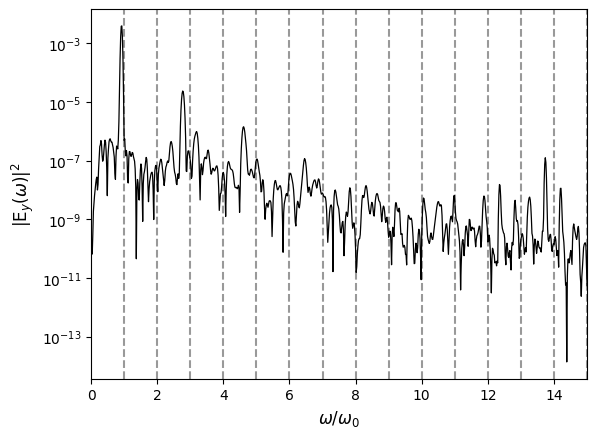

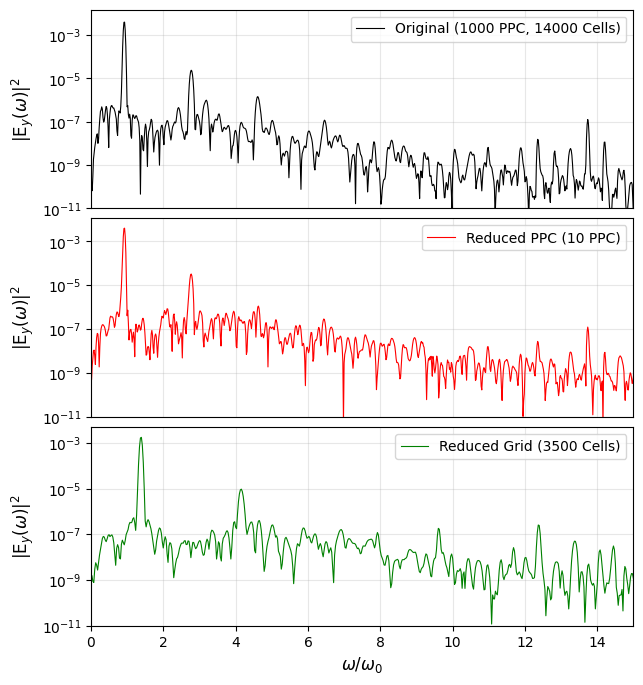

In [ ]:
Ey_FT, omega_vals, _, _ = run_FFT(ds)
Ey_FT_2, omega_vals_2, _, _ = run_FFT(ds2)
Ey_FT_3, omega_vals_3, _, _ = run_FFT(ds3)


plt.figure()
plt.semilogy(omega_vals/omega0, np.abs(Ey_FT)**2, color='black', linewidth=0.9)
plt.xlim(0, 15)
plt.xlabel(r'$\omega/\omega_0$', fontsize=12)
plt.ylabel(r'|E$_y$($\omega$)|$^2$', fontsize=12)
for i in range(1,16):
    plt.axvline(i, alpha=0.4, color='black', linestyle="--", label=r'n$\omega_0$')
plt.show()


fig, axes = plt.subplots(3, 1, sharex=True, figsize=(7, 8), gridspec_kw={'hspace': 0.05})

axes[0].semilogy(omega_vals/omega0, np.abs(Ey_FT)**2, color='black', linewidth=0.8, label="Original (1000 PPC, 14000 Cells)")
axes[0].set_ylabel(r'|E$_y$($\omega$)|$^2$', fontsize=12)
axes[0].set_ylim(1e-11, None)
axes[0].legend(loc="upper right")
axes[0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

axes[1].semilogy(omega_vals_2/omega0, np.abs(Ey_FT_2)**2, color='red', linewidth=0.8, label="Reduced PPC (10 PPC)")
axes[1].set_ylabel(r'|E$_y$($\omega$)|$^2$', fontsize=12)
axes[1].set_ylim(1e-11, None)
axes[1].legend(loc="upper right")
axes[1].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

axes[2].semilogy(omega_vals_3/omega0, np.abs(Ey_FT_3)**2, color='green', linewidth=0.8, label="Reduced Grid (3500 Cells)")
axes[2].set_ylabel(r'|E$_y$($\omega$)|$^2$', fontsize=12)
axes[2].set_ylim(1e-11, None)
axes[2].set_xlabel(r'$\omega/\omega_0$', fontsize=12)
axes[2].set_xlim(0, 15)
axes[2].legend(loc="upper right")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.show()

## Section 3.2

Figure 3 in report + peak finding

In [ ]:
ds16 = xr.open_mfdataset('section_3.2/' + 'inten_16' + '/*.sdf', preprocess=SDFPreprocess())
ds18 = xr.open_mfdataset('section_3.2/' + 'inten_18' + '/*.sdf', preprocess=SDFPreprocess())
ds19 = xr.open_mfdataset('section_3.2/' + 'inten_19' + '/*.sdf', preprocess=SDFPreprocess())
ds20 = xr.open_mfdataset('section_3.2/' + 'inten_20' + '/*.sdf', preprocess=SDFPreprocess())

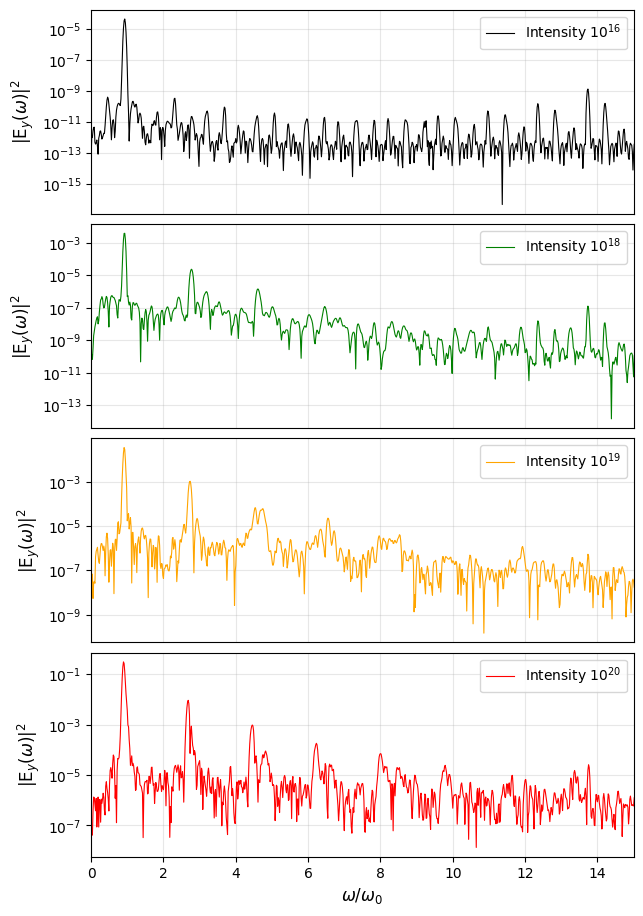

In [ ]:
Ey_FT_16, omega_vals_16, _, _ = run_FFT(ds16)
Ey_FT_18, omega_vals_18, _, _ = run_FFT(ds18)
Ey_FT_19, omega_vals_19, _, _ = run_FFT(ds19)
Ey_FT_20, omega_vals_20, _, _ = run_FFT(ds20)


fig, axes = plt.subplots(4, 1, sharex=True, figsize=(7, 11), gridspec_kw={'hspace': 0.05})

axes[0].semilogy(omega_vals_16/omega0, np.abs(Ey_FT_16)**2, color='black', linewidth=0.8, label=r"Intensity $10^{16}$")
axes[0].set_ylabel(r'|E$_y$($\omega$)|$^2$', fontsize=12)
axes[0].legend(loc="upper right")
axes[0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

axes[1].semilogy(omega_vals_18/omega0, np.abs(Ey_FT_18)**2, color='green', linewidth=0.8, label=r"Intensity $10^{18}$")
axes[1].set_ylabel(r'|E$_y$($\omega$)|$^2$', fontsize=12)
axes[1].legend(loc="upper right")
axes[1].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

axes[2].semilogy(omega_vals_19/omega0, np.abs(Ey_FT_19)**2, color='orange', linewidth=0.8, label=r"Intensity $10^{19}$")
axes[2].set_ylabel(r'|E$_y$($\omega$)|$^2$', fontsize=12)
axes[2].legend(loc="upper right")
axes[2].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

axes[3].semilogy(omega_vals_20/omega0, np.abs(Ey_FT_20)**2, color='red', linewidth=0.8, label=r"Intensity $10^{20}$")
axes[3].set_ylabel(r'|E$_y$($\omega$)|$^2$', fontsize=12)
axes[3].set_xlabel(r'$\omega/\omega_0$', fontsize=12)
axes[3].set_xlim(0, 15)
axes[3].legend(loc="upper right")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.show()

Detected harmonics:
  H1: omega = 0.930 omega0 | theoretical = 1.0 omega0 | power = 4.489e-05


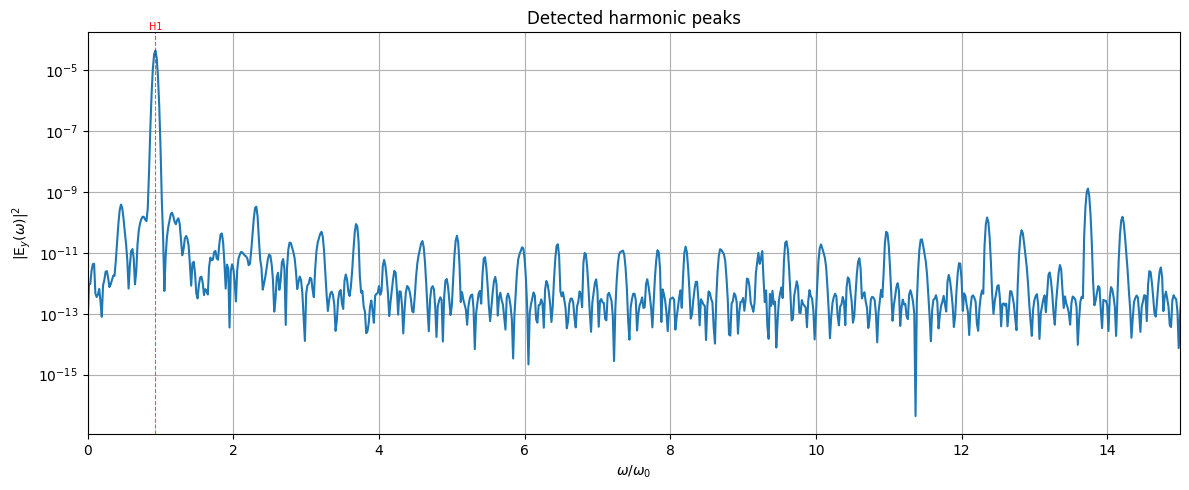

Detected harmonics:
  H1: omega = 0.930 omega0 | theoretical = 1.0 omega0 | power = 3.965e-03
  H3: omega = 2.772 omega0 | theoretical = 3.0 omega0 | power = 2.388e-05
  H5: omega = 4.614 omega0 | theoretical = 5.0 omega0 | power = 1.446e-06
  H7: omega = 6.456 omega0 | theoretical = 7.0 omega0 | power = 1.186e-07


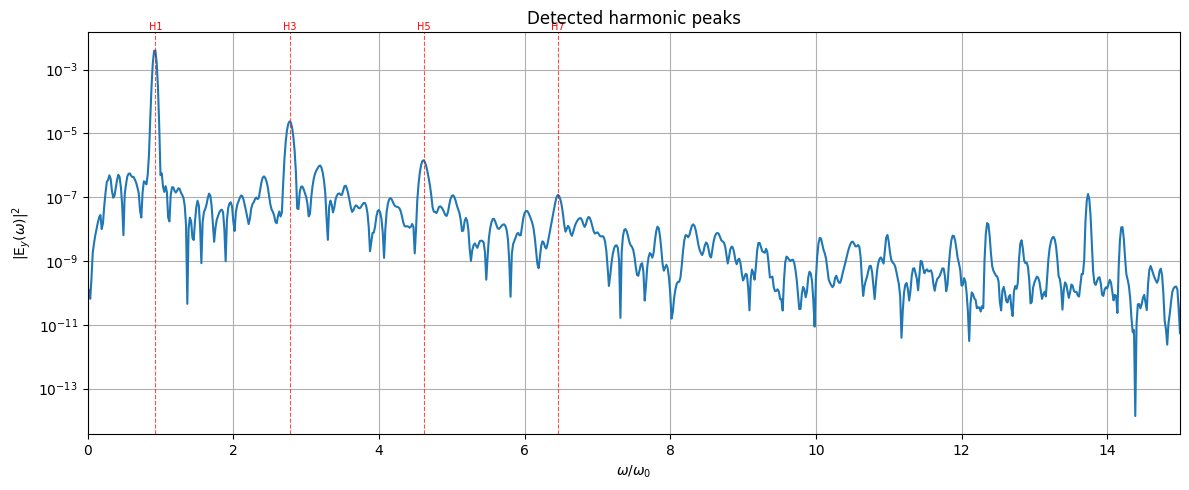

Detected harmonics:
  H1: omega = 0.912 omega0 | theoretical = 1.0 omega0 | power = 3.389e-02
  H3: omega = 2.737 omega0 | theoretical = 3.0 omega0 | power = 1.034e-03
  H5: omega = 4.544 omega0 | theoretical = 5.0 omega0 | power = 6.630e-05
  H7: omega = 6.544 omega0 | theoretical = 7.0 omega0 | power = 2.225e-05
  H9: omega = 8.526 omega0 | theoretical = 9.0 omega0 | power = 4.037e-06
  H13: omega = 11.930 omega0 | theoretical = 13.0 omega0 | power = 1.193e-06


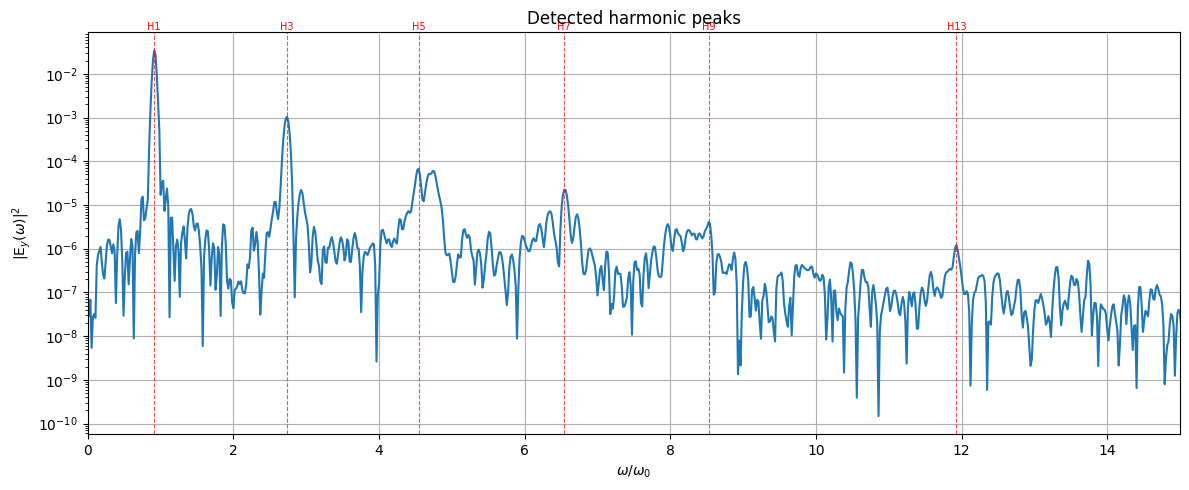

Detected harmonics:
  H1: omega = 0.895 omega0 | theoretical = 1.0 omega0 | power = 3.105e-01
  H3: omega = 2.684 omega0 | theoretical = 3.0 omega0 | power = 9.258e-03
  H5: omega = 4.456 omega0 | theoretical = 5.0 omega0 | power = 9.724e-04
  H7: omega = 6.228 omega0 | theoretical = 7.0 omega0 | power = 1.828e-04
  H9: omega = 8.000 omega0 | theoretical = 9.0 omega0 | power = 7.101e-05
  H11: omega = 9.789 omega0 | theoretical = 11.0 omega0 | power = 2.436e-05
  H13: omega = 11.649 omega0 | theoretical = 13.0 omega0 | power = 9.745e-06


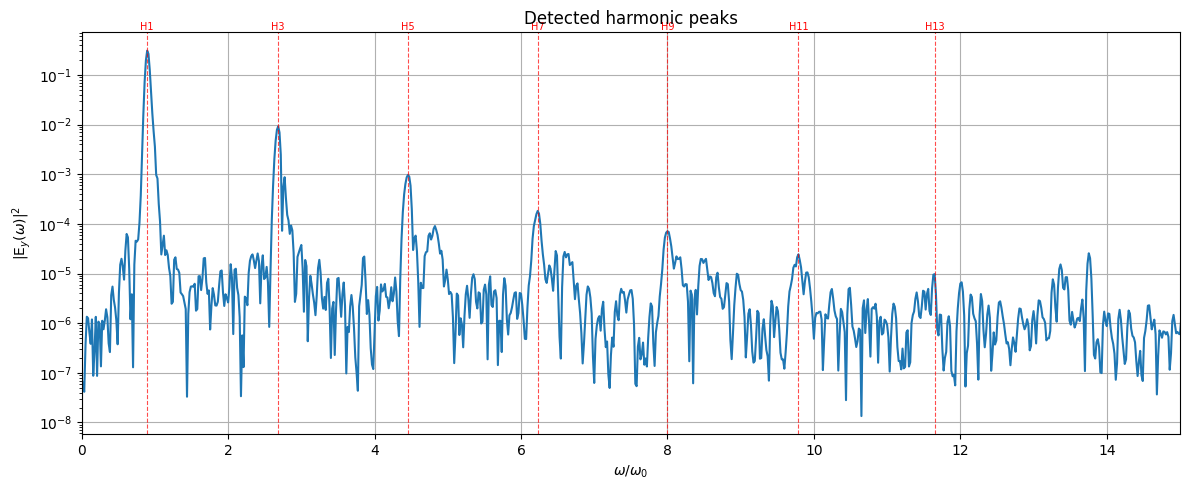

In [61]:
harmonic_peak_omegas_16, harmonic_peak_powers_16 = find_harmonic_peaks(
    omega_vals_16, Ey_FT_16, max_harmonic=14, plot=True, odd_only=True
)

harmonic_peak_omegas_18, harmonic_peak_powers_18 = find_harmonic_peaks(
    omega_vals_18, Ey_FT_18, max_harmonic=14, plot=True, odd_only=True
)

harmonic_peak_omegas_19, harmonic_peak_powers_19 = find_harmonic_peaks(
    omega_vals_19, Ey_FT_19, max_harmonic=14, plot=True, odd_only=True
)

harmonic_peak_omegas_20, harmonic_peak_powers_20 = find_harmonic_peaks(
    omega_vals_20, Ey_FT_20, max_harmonic=14, plot=True, odd_only=True
)

## Section 3.3

Figures 4 and 5 in report + data extraction

Detected harmonics:
  H1: omega = 0.895 omega0 | theoretical = 1.0 omega0 | power = 2.035e-01
  H2: omega = 1.789 omega0 | theoretical = 2.0 omega0 | power = 5.529e-02
  H3: omega = 2.702 omega0 | theoretical = 3.0 omega0 | power = 1.411e-03
  H4: omega = 3.579 omega0 | theoretical = 4.0 omega0 | power = 8.064e-03
  H5: omega = 4.491 omega0 | theoretical = 5.0 omega0 | power = 8.154e-04
  H6: omega = 5.368 omega0 | theoretical = 6.0 omega0 | power = 4.241e-04
  H7: omega = 6.263 omega0 | theoretical = 7.0 omega0 | power = 7.423e-04
  H8: omega = 7.158 omega0 | theoretical = 8.0 omega0 | power = 7.192e-05
  H9: omega = 8.035 omega0 | theoretical = 9.0 omega0 | power = 1.385e-04
  H10: omega = 8.930 omega0 | theoretical = 10.0 omega0 | power = 1.564e-04
  H11: omega = 9.807 omega0 | theoretical = 11.0 omega0 | power = 2.832e-05
  H12: omega = 10.684 omega0 | theoretical = 12.0 omega0 | power = 4.361e-05
Detected harmonics:
  H1: omega = 0.895 omega0 | theoretical = 1.0 omega0 | power = 2

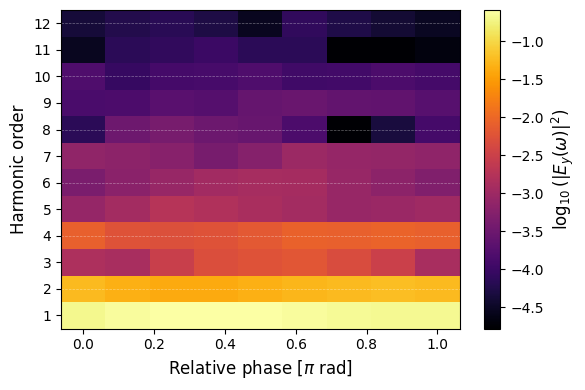

In [ ]:
rel_phases, harmonic_orders, spectral_map = plot_spectral_map('split_8020')

In [ ]:
# Determine the ratio of the maximum and minimum spectral intensities to see which harmonics vary the most
for i, n in enumerate(harmonic_orders):
    harmonic_row = spectral_map[:, i]
    real_vals = harmonic_row[~np.isnan(harmonic_row)]
    ratio = real_vals.max() / real_vals.min()  # ratio
    print(f"H{n}: max = {real_vals.max():.3e}, min = {real_vals.min():.3e}, ratio = {ratio:.2f}")

H1: max = 2.557e-01, min = 2.035e-01, ratio = 1.26
H2: max = 5.925e-02, min = 4.048e-02, ratio = 1.46
H3: max = 6.246e-03, min = 1.269e-03, ratio = 4.92
H4: max = 8.917e-03, min = 5.261e-03, ratio = 1.69
H5: max = 1.815e-03, min = 8.154e-04, ratio = 2.23
H6: max = 1.245e-03, min = 4.241e-04, ratio = 2.94
H7: max = 9.356e-04, min = 4.007e-04, ratio = 2.33
H8: max = 3.925e-04, min = 4.647e-05, ratio = 8.45
H9: max = 2.843e-04, min = 1.385e-04, ratio = 2.05
H10: max = 1.564e-04, min = 8.923e-05, ratio = 1.75
H11: max = 1.007e-04, min = 1.655e-05, ratio = 6.08
H12: max = 7.788e-05, min = 2.900e-05, ratio = 2.69


Detected harmonics:
  H1: omega = 0.895 omega0 | theoretical = 1.0 omega0 | power = 2.035e-01
  H2: omega = 1.789 omega0 | theoretical = 2.0 omega0 | power = 5.529e-02
  H3: omega = 2.702 omega0 | theoretical = 3.0 omega0 | power = 1.411e-03
  H4: omega = 3.579 omega0 | theoretical = 4.0 omega0 | power = 8.064e-03
  H5: omega = 4.491 omega0 | theoretical = 5.0 omega0 | power = 8.154e-04
  H6: omega = 5.368 omega0 | theoretical = 6.0 omega0 | power = 4.241e-04
  H7: omega = 6.263 omega0 | theoretical = 7.0 omega0 | power = 7.423e-04
  H8: omega = 7.158 omega0 | theoretical = 8.0 omega0 | power = 7.192e-05
  H9: omega = 8.035 omega0 | theoretical = 9.0 omega0 | power = 1.385e-04
  H10: omega = 8.930 omega0 | theoretical = 10.0 omega0 | power = 1.564e-04
  H11: omega = 9.807 omega0 | theoretical = 11.0 omega0 | power = 2.832e-05
  H12: omega = 10.684 omega0 | theoretical = 12.0 omega0 | power = 4.361e-05
H3 | amplitude = 1.734e+12 V/m | phase offset = -1993.059 rad
Detected harmonics:
  H

<Figure size 640x480 with 0 Axes>

Detected harmonics:
  H1: omega = 0.895 omega0 | theoretical = 1.0 omega0 | power = 2.035e-01
  H2: omega = 1.789 omega0 | theoretical = 2.0 omega0 | power = 5.529e-02
  H3: omega = 2.702 omega0 | theoretical = 3.0 omega0 | power = 1.411e-03
  H4: omega = 3.579 omega0 | theoretical = 4.0 omega0 | power = 8.064e-03
  H5: omega = 4.491 omega0 | theoretical = 5.0 omega0 | power = 8.154e-04
  H6: omega = 5.368 omega0 | theoretical = 6.0 omega0 | power = 4.241e-04
  H7: omega = 6.263 omega0 | theoretical = 7.0 omega0 | power = 7.423e-04
  H8: omega = 7.158 omega0 | theoretical = 8.0 omega0 | power = 7.192e-05
  H9: omega = 8.035 omega0 | theoretical = 9.0 omega0 | power = 1.385e-04
  H10: omega = 8.930 omega0 | theoretical = 10.0 omega0 | power = 1.564e-04
  H11: omega = 9.807 omega0 | theoretical = 11.0 omega0 | power = 2.832e-05
  H12: omega = 10.684 omega0 | theoretical = 12.0 omega0 | power = 4.361e-05
H8 | amplitude = 5.393e+11 V/m | phase offset = -5297.997 rad
Detected harmonics:
  H

<Figure size 640x480 with 0 Axes>

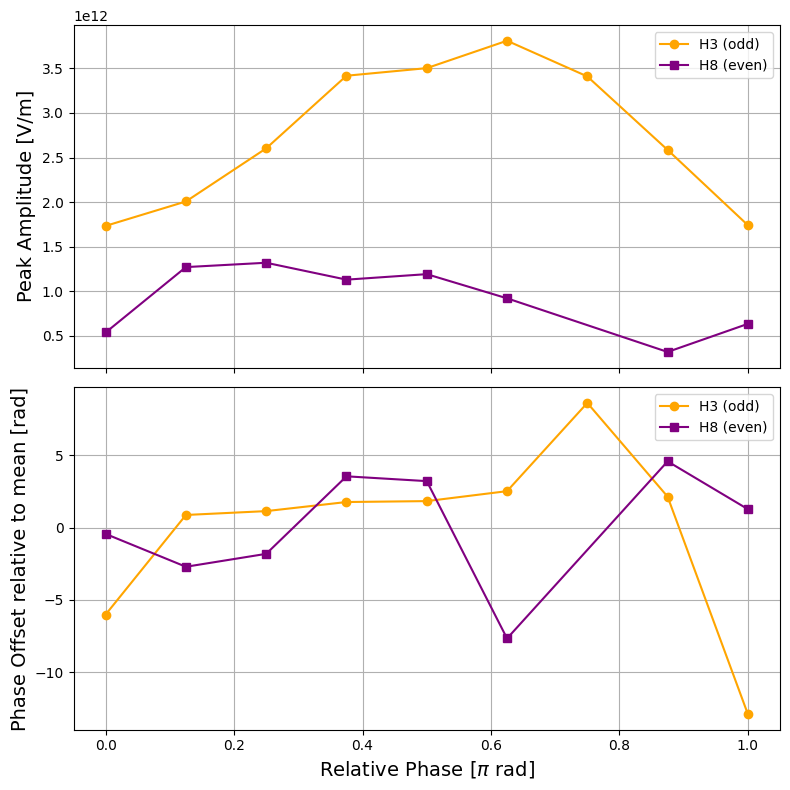

In [ ]:
rel_phases_h3, amp_h3, phase_h3 = run_harmonic_analysis('split_8020', 3,  max_harmonic=12, plot=False)
rel_phases_h8, amp_h8, phase_h8 = run_harmonic_analysis('split_8020', 8, max_harmonic=12, plot=False)

# Subtract mean for visual comparison since the means of H3 and H8 are very different
phase_h3_rel = phase_h3 - np.mean(phase_h3)
phase_h8_rel = phase_h8 - np.mean(phase_h8)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

ax1.plot(rel_phases_h3 / np.pi, amp_h3, 'o-', color='orange', label='H3 (odd)')
ax1.plot(rel_phases_h8 / np.pi, amp_h8, 's-', color='purple', label='H8 (even)')
ax1.set_ylabel('Peak Amplitude [V/m]', fontsize=14)
ax1.legend()
ax1.grid(True)

ax2.plot(rel_phases_h3 / np.pi, phase_h3_rel, 'o-', color='orange', label='H3 (odd)')
ax2.plot(rel_phases_h8 / np.pi, phase_h8_rel, 's-', color='purple', label='H8 (even)')
ax2.set_ylabel(r'Phase Offset relative to mean [rad]', fontsize=14)
ax2.set_xlabel(r'Relative Phase [$\pi$ rad]', fontsize=14)
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [36]:
print(f"H3 has a minimum amplitude of {amp_h3.min()/1e12:.2f}e12, and a maximum amplitude of {amp_h3.max()/1e12:.2f}e12.")
print(f"H8 has a minimum amplitude of {amp_h8.min()/1e12:.2f}e12, and a maximum amplitude of {amp_h8.max()/1e12:.2f}e12.")

H3 has a minimum amplitude of 1.73e12, and a maximum amplitude of 3.81e12.
H8 has a minimum amplitude of 0.32e12, and a maximum amplitude of 1.32e12.
